## Setup
Import necessary packages and define function to load metrics from filepath.

In [5]:
import json
import matplotlib.pyplot as plt
import jax.numpy as jp
import dill

def load_metrics(path):
    with open(path, "rb") as f:
        return dill.load(f)

## Plot metrics
Plot the metrics for proprioceptive and exteroceptive data.

Case 1 Proprioceptive: Mean linear velocity tracking error: 0.047 ± 0.168
Case 1 Proprioceptive: Torso height mean: -0.111, std: 0.110
Case 1 Exteroceptive: Mean linear velocity tracking error: 0.035 ± 0.095
Case 1 Exteroceptive: Torso height mean: -0.146, std: 0.108


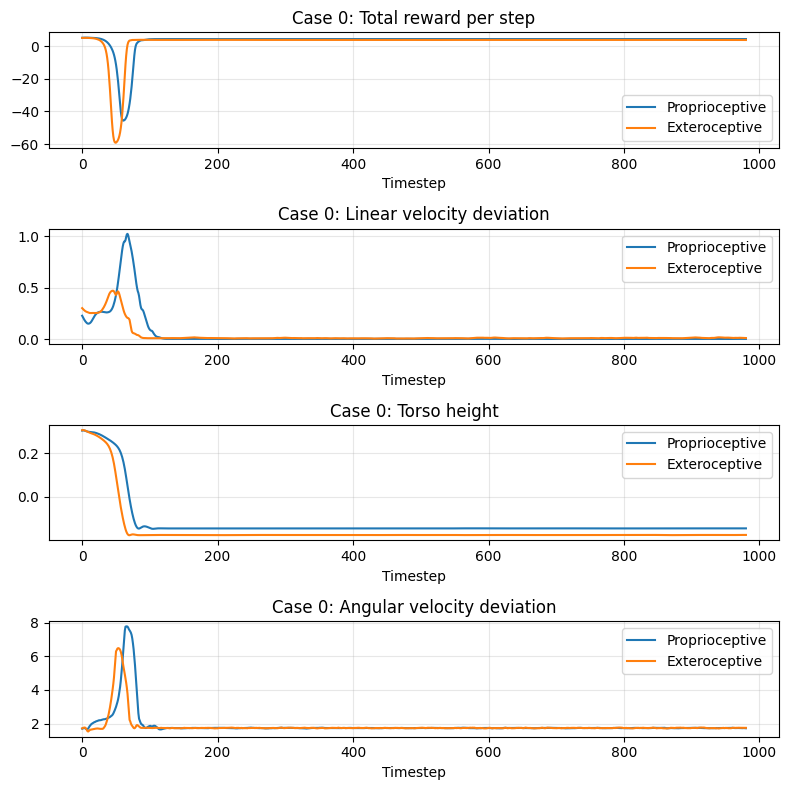

Case 2 Proprioceptive: Mean linear velocity tracking error: 0.505 ± 0.058
Case 2 Proprioceptive: Torso height mean: 0.312, std: 0.003
Case 2 Exteroceptive: Mean linear velocity tracking error: 0.505 ± 0.049
Case 2 Exteroceptive: Torso height mean: 0.321, std: 0.003


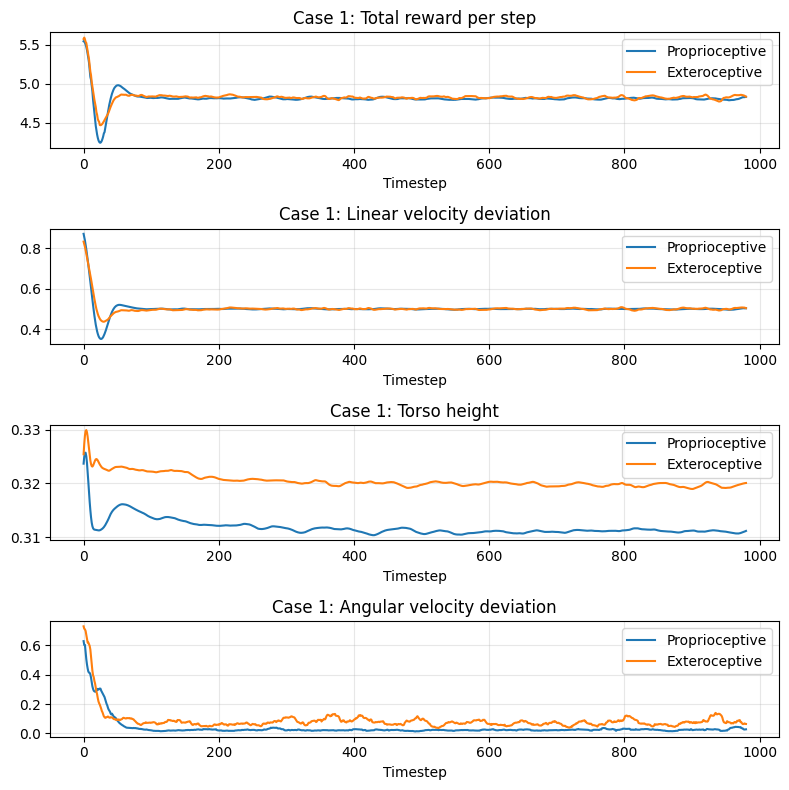

Case 3 Proprioceptive: Mean linear velocity tracking error: 1.006 ± 0.067
Case 3 Proprioceptive: Torso height mean: 0.299, std: 0.003
Case 3 Exteroceptive: Mean linear velocity tracking error: 1.006 ± 0.056
Case 3 Exteroceptive: Torso height mean: 0.309, std: 0.003


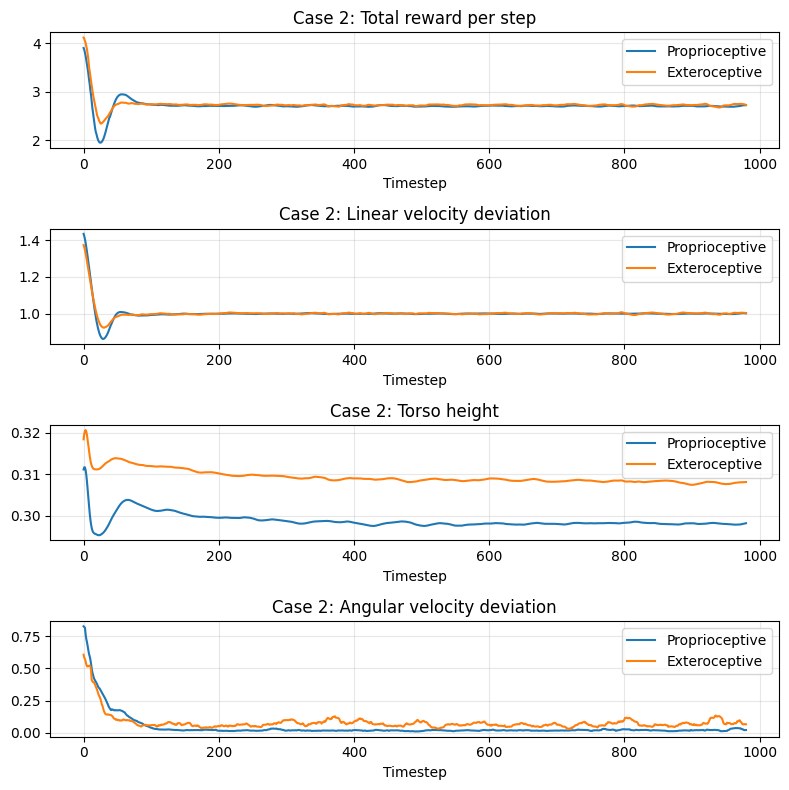

Case 4 Proprioceptive: Mean linear velocity tracking error: 0.502 ± 0.016
Case 4 Proprioceptive: Torso height mean: 0.301, std: 0.003
Case 4 Exteroceptive: Mean linear velocity tracking error: 0.500 ± 0.009
Case 4 Exteroceptive: Torso height mean: 0.306, std: 0.002


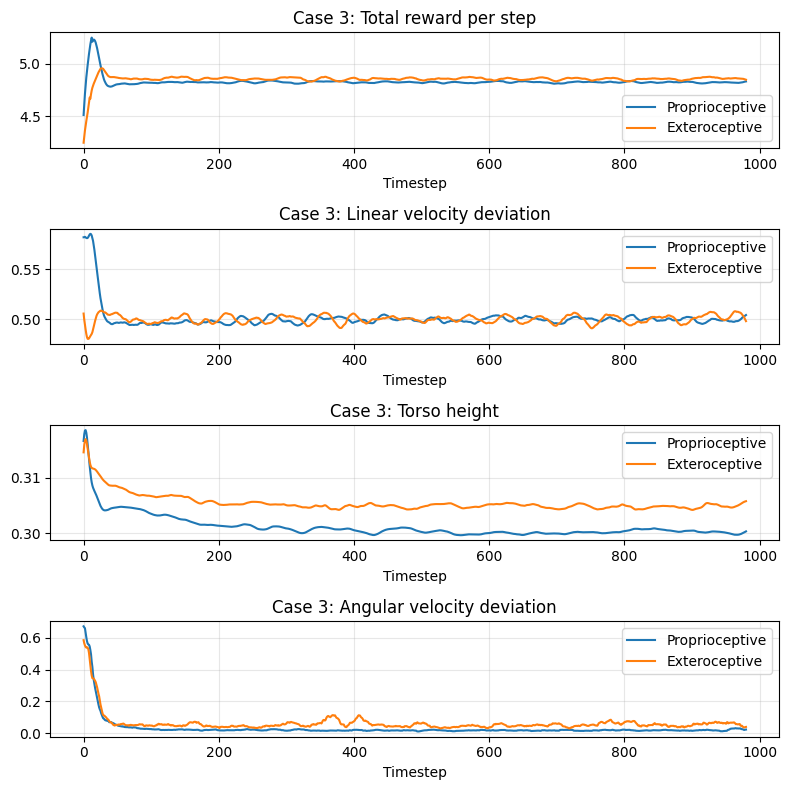

Case 5 Proprioceptive: Mean linear velocity tracking error: 1.000 ± 0.010
Case 5 Proprioceptive: Torso height mean: 0.281, std: 0.005
Case 5 Exteroceptive: Mean linear velocity tracking error: 0.987 ± 0.060
Case 5 Exteroceptive: Torso height mean: -0.149, std: 0.091


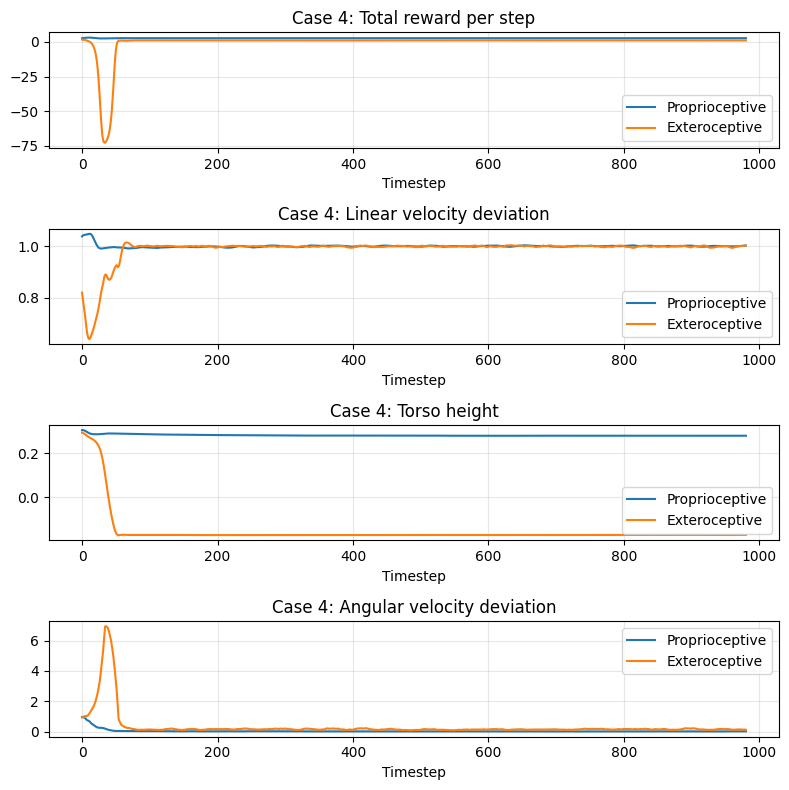

Case 6 Proprioceptive: Mean linear velocity tracking error: 0.711 ± 0.035
Case 6 Proprioceptive: Torso height mean: 0.298, std: 0.003
Case 6 Exteroceptive: Mean linear velocity tracking error: 0.710 ± 0.031
Case 6 Exteroceptive: Torso height mean: 0.305, std: 0.002


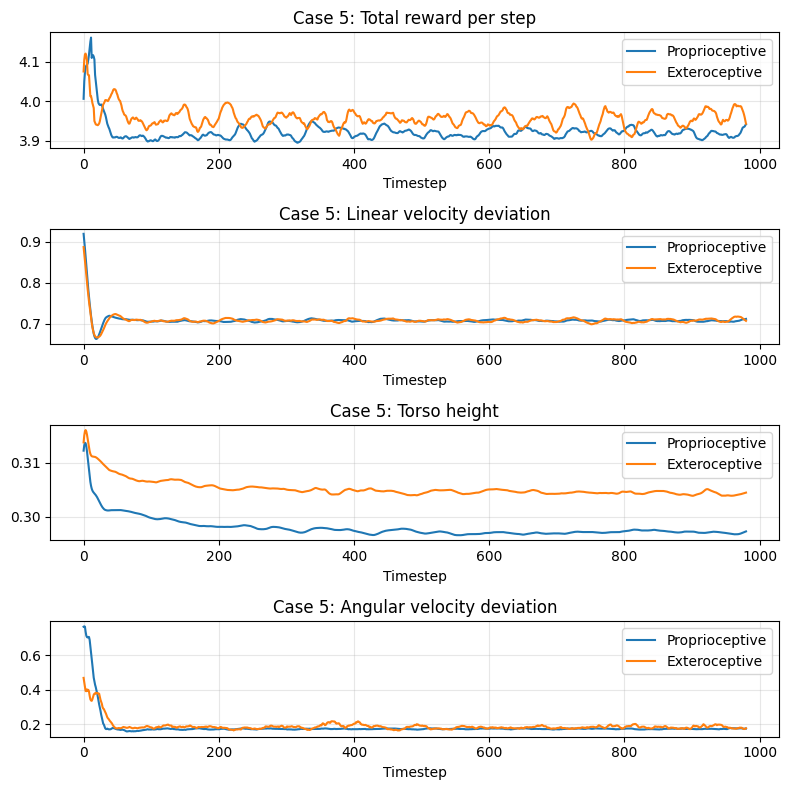

In [6]:
proprio_metrics = load_metrics("metrics/proprioceptive_metrics.dill")
extero_metrics = load_metrics("metrics/exteroceptive_metrics.dill")

policies = {
    "Proprioceptive": proprio_metrics,
    "Exteroceptive": extero_metrics,
}

policy_colors = {
    "Proprioceptive": "tab:blue",
    "Exteroceptive": "tab:orange",
}

cases = len(proprio_metrics)
window = 20

for i in range(cases):
    fig, axs = plt.subplots(4, 1, figsize=(8, 8))  # new figure each loop

    for policy_name, metric in policies.items():
        smooth_reward = jp.convolve(jp.array(metric[i]["total_reward"]), jp.ones(window)/window, mode='valid')
        axs[0].plot(smooth_reward, label=policy_name, color=policy_colors[policy_name])

        smooth_lin_vel = jp.convolve(jp.array(metric[i]["linear_velocity_deviation"]), jp.ones(window)/window, mode='valid')
        axs[1].plot(smooth_lin_vel, label=policy_name, color=policy_colors.get(policy_name))

        smooth_torso = jp.convolve(jp.array(metric[i]["torso_heights"]), jp.ones(window)/window, mode="valid")
        axs[2].plot(smooth_torso, label=policy_name, color=policy_colors[policy_name])

        smooth_ang_vel = jp.convolve(jp.array(metric[i]["angvel_deviation"]), jp.ones(window)/window, mode="valid")
        axs[3].plot(smooth_ang_vel, label=policy_name, color=policy_colors[policy_name])

        # Get mean and std lin vel error
        mean_error = jp.mean(jp.array(metric[i]["linear_velocity_deviation"]))
        std_error = jp.std(jp.array(metric[i]["linear_velocity_deviation"]))
        print(f"Case {i+1} {policy_name}: Mean linear velocity tracking error: {mean_error:.3f} ± {std_error:.3f}")

        # Get mean and std torso height
        mean_height = jp.mean(jp.array(metric[i]["torso_heights"]))
        std_height = jp.std(jp.array(metric[i]["torso_heights"]))
        print(f"Case {i+1} {policy_name}: Torso height mean: {mean_height:.3f}, std: {std_height:.3f}")

    axs[0].set_title(f"Case {i}: Total reward per step")
    axs[1].set_title(f"Case {i}: Linear velocity deviation")
    axs[2].set_title(f"Case {i}: Torso height")
    axs[3].set_title(f"Case {i}: Angular velocity deviation")
    
    for ax in axs:
        ax.set_xlabel("Timestep")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()